# LC-DA-CA1 schematic model (peak-tuning notebook)

Author: Dinghao Luo  
Date  : 30 March 2026

This notebook is the active peak-tuning branch of [general_model_manuscript_bootstrap.ipynb](./general_model_manuscript_bootstrap.ipynb). It keeps the manuscript model structure, but lets us tune the synthetic population toward the empirical PyrUp and PyrDown profiles without overwriting the baseline manuscript file.

The current branch uses `20` paired synthetic-population replicates. Within each replicate, baseline, `1.5x` LC activation, and partial DA blockade are all applied to the **same** sampled CA1 population.

Key fixed analysis choices in this branch:
- class-definition thresholds remain fixed at `PyrDown <= 2/3` and `PyrUp >= 3/2`
- dopamine enters CA1 as an **additive current**, with amplitude set by each cell's a priori DA sensitivity and a sigmoid transform of its current no-DA firing-rate proxy
- the intrinsic tau acts on the full latent CA1 state, and `softplus` is applied only at the output stage to convert that state into a non-negative firing rate

The working model is therefore:

\[
x_i(t)=b_i+w_i^R R(t)+w_i^W W(t)
\]
\[
I_i^{DA}(t)=g_i\,\sigma\!\left(\frac{\mathrm{softplus}(x_i(t))-r_{1/2}}{k_r}\right)\,D_{\mathrm{eff}}(t)
\]
\[
\tau_i \frac{du_i(t)}{dt}=-u_i(t)+x_i(t)+I_i^{DA}(t)
\]
\[
r_i(t)=\mathrm{softplus}(u_i(t))
\]

This is still a compact phenomenological model rather than a biophysical circuit model. Its purpose is to test whether a simple LC-DA-CA1 architecture can reproduce the manuscript-level shifts in PyrUp and PyrDown proportions and firing-rate profiles under repeated synthetic-population resampling.


In [185]:
# imports
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt

from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from scipy.stats import ttest_rel, wilcoxon

for _root in (Path.cwd(), Path.cwd().parent):
    _utils = _root / 'utils'
    if _utils.exists():
        _utils_str = str(_utils)
        if _utils_str not in sys.path:
            sys.path.insert(0, _utils_str)
        break

import plotting_functions as pf

warnings.filterwarnings('ignore', message='Matplotlib is currently using agg')


In [186]:
@dataclass
class PARAMS:
    # simulation grid
    dt: float = 0.01
    t_pre: float = 1.00
    t_post: float = 6.00

    # bootstrap controls
    n_bootstrap: int = 20
    seed_start: int = 0
    lc_activation_fold: float = 1.50

    # population size
    n_cells: int = 1000

    # population priors
    baseline_mean: float = 1.50
    baseline_sd: float = 0.35

    wR_mean: float = 0.70
    wR_sd: float = 0.60
    wW_mean: float = 0.28
    wW_sd: float = 1.00

    # additive DA current
    frac_da_targ: float = 0.35
    da_half_rate: float = 2.20
    da_rate_slope: float = 0.45
    da_gain_global: float = 1.04
    da_gain_targeted_extra: float = 0.34
    da_block_scale: float = 0.70
    da_mod_delay: float = 0.35
    da_gate_mid: float = 0.15
    da_gate_scale: float = 0.12

    # cell-intrinsic recovery acting on the full latent CA1 state
    intrinsic_tau_mean: float = 2.00
    intrinsic_tau_sd: float = 0.20
    intrinsic_tau_min: float = 0.35
    intrinsic_tau_max: float = 2.60
    intrinsic_tau_away_scale: float = 0.15

    # output nonlinearity / output limits
    softplus_beta: float = 2.00
    max_rate: float = 20.00

    # run-drive shape (same smooth pulse family as reward, but with a faster rise and slower fall)
    run_on_mid: float = 0.27
    run_off_mid: float = 2.05
    run_rise_scale: float = 0.16
    run_fall_scale: float = 0.28

    # reward-drive shape
    reward_on_mid: float = 0.52
    reward_off_mid: float = 1.38
    reward_rise_scale: float = 0.13
    reward_fall_scale: float = 0.27

    # drive amplitudes
    run_amp: float = 0.62
    reward_amp: float = 0.85
    da_dip_amp: float = -0.50

    # DA dip timing
    da_dip_t: float = -0.25
    da_dip_tau: float = 0.20

    # LC drive shape
    lc_baseline: float = 1.00
    lc_amp: float = 1.50
    lc_mu: float = 0.00
    lc_sigma: float = 0.20

    # LC -> DA conversion (single-tau shaped DA kernel)
    lc_to_da_gain: float = 1.25
    da_tau_decay: float = 0.28
    da_kernel_order: int = 3

    # population analysis
    pre_window: tuple = (-1.00, -0.50)
    post_window: tuple = (0.80, 2.20)
    up_thresh: float = 1.50
    down_thresh: float = 2 / 3

    # numerical safeguard
    eps: float = 1e-6


class_colors = {
    'is_up': 'firebrick',
    'is_other': 'grey',
    'is_down': 'purple'
}

condition_colors = {
    'baseline': '0.35',
    'lc': 'royalblue',
    'blocked': class_colors['is_down'],
    'da_targeted': class_colors['is_up'],
    'not_targeted': '0.45'
}


In [187]:
# helper functions

def window_mask(t, window):
    return (t >= window[0]) & (t < window[1])


def response_strength(rates, t, p):
    pre_mask = window_mask(t, p.pre_window)
    post_mask = window_mask(t, p.post_window)

    pre_mean = np.mean(rates[:, pre_mask], axis=1)
    post_mean = np.mean(rates[:, post_mask], axis=1)
    return post_mean / (pre_mean + p.eps)


def classify_cells(resp, p):
    is_up = resp >= p.up_thresh
    is_down = resp <= p.down_thresh
    is_other = ~(is_up | is_down)
    return {
        'is_up': is_up,
        'is_down': is_down,
        'is_other': is_other,
    }


def safe_mean_trace(rate_matrix, mask):
    if np.sum(mask) == 0:
        return np.full(rate_matrix.shape[1], np.nan)
    return np.mean(rate_matrix[mask], axis=0)


def sem(values, axis=0):
    values = np.asarray(values, dtype=float)
    count = np.sum(np.isfinite(values), axis=axis)
    spread = np.nanstd(values, axis=axis, ddof=1)
    out = spread / np.sqrt(np.maximum(count, 1))
    if np.isscalar(out):
        return np.nan if count <= 1 else float(out)
    out = np.asarray(out, dtype=float)
    out = np.where(count > 1, out, np.nan)
    return out


def describe_scalar(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanmean(values)), float(sem(values, axis=0))


def baseline_subtracted_traces(traces, t, window):
    traces = np.asarray(traces, dtype=float)
    baseline = np.mean(traces[:, window_mask(t, window)], axis=1, keepdims=True)
    return traces - baseline


def format_p_value(p):
    if not np.isfinite(p):
        return 'nan'
    if p < 1e-4:
        return '<1e-4'
    return f'{p:.4f}'


def paired_test_summary(left, right):
    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    mask = np.isfinite(left) & np.isfinite(right)
    left = left[mask]
    right = right[mask]

    if len(left) == 0:
        return {
            'n': 0,
            'mean_left': np.nan,
            'mean_right': np.nan,
            'mean_diff': np.nan,
            'ttest_stat': np.nan,
            'ttest_p': np.nan,
            'wilcoxon_stat': np.nan,
            'wilcoxon_p': np.nan,
        }

    t_res = ttest_rel(right, left, nan_policy='omit')
    try:
        w_res = wilcoxon(right, left, zero_method='wilcox', method='approx')
        w_stat = float(w_res.statistic)
        w_p = float(w_res.pvalue)
    except ValueError:
        w_stat = np.nan
        w_p = np.nan

    return {
        'n': int(len(left)),
        'mean_left': float(np.mean(left)),
        'mean_right': float(np.mean(right)),
        'mean_diff': float(np.mean(right - left)),
        'ttest_stat': float(t_res.statistic),
        'ttest_p': float(t_res.pvalue),
        'wilcoxon_stat': w_stat,
        'wilcoxon_p': w_p,
    }


def print_paired_summary(label, left, right):
    summary = paired_test_summary(left, right)
    print(
        f'{label}: '
        f'delta = {summary["mean_diff"]:.2f}, '
        f'paired t p = {format_p_value(summary["ttest_p"])}, '
        f'Wilcoxon p = {format_p_value(summary["wilcoxon_p"])}'
    )


def plot_mean_sem(ax, t, traces, color, label, linestyle='-', alpha_fill=0.18):
    traces = np.asarray(traces, dtype=float)
    mean_trace = np.nanmean(traces, axis=0)
    sem_trace = sem(traces, axis=0)
    ax.plot(t, mean_trace, color=color, linewidth=2, linestyle=linestyle, label=label)
    ax.fill_between(
        t,
        mean_trace - sem_trace,
        mean_trace + sem_trace,
        color=color,
        alpha=alpha_fill,
        linewidth=0,
    )


def set_trace_ylim(ax, *trace_sets, pad_frac=0.08, lower_floor=0.0):
    lows = []
    highs = []
    for traces in trace_sets:
        traces = np.asarray(traces, dtype=float)
        if traces.size == 0:
            continue
        if traces.ndim == 1:
            mean_trace = traces
            sem_trace = np.zeros_like(mean_trace)
        else:
            mean_trace = np.nanmean(traces, axis=0)
            sem_trace = sem(traces, axis=0)
        lows.append(float(np.nanmin(mean_trace - sem_trace)))
        highs.append(float(np.nanmax(mean_trace + sem_trace)))

    if not lows or not highs:
        return

    ymin = min(lows)
    ymax = max(highs)
    span = ymax - ymin
    if not np.isfinite(span) or span <= 0:
        span = max(abs(ymax), 1.0) * 0.1
    pad = span * pad_frac
    ax.set_ylim(max(lower_floor, ymin - pad), ymax + pad)


def paired_ylim(*arrays, lower_floor=0.0, pad_frac=0.35, min_pad=2.5, anchor_floor=None):
    finite = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float).ravel()
        arr = arr[np.isfinite(arr)]
        if arr.size:
            finite.append(arr)
    if not finite:
        return None
    values = np.concatenate(finite)
    vmin = float(np.min(values))
    vmax = float(np.max(values))
    span = vmax - vmin
    pad = max(span * pad_frac, min_pad)
    ymin = vmin - pad
    if anchor_floor is not None:
        ymin = min(float(anchor_floor), ymin)
    return (max(lower_floor, ymin), vmax + pad)


def half_cosine(tt, t0, t1, y0, y1):
    s = np.clip((tt - t0) / (t1 - t0), 0.0, 1.0)
    return y0 + (y1 - y0) * 0.5 * (1.0 - np.cos(np.pi * s))


def sigmoid(x, midpoint, scale):
    scale = max(scale, 1e-6)
    return 1.0 / (1.0 + np.exp(-(x - midpoint) / scale))


def softplus(x, beta):
    xb = beta * np.asarray(x, dtype=float)
    return (np.log1p(np.exp(-np.abs(xb))) + np.maximum(xb, 0.0)) / beta


def smooth_pulse(tt, onset_mid, offset_mid, rise_scale, fall_scale, amplitude, eps):
    pulse = sigmoid(tt, onset_mid, rise_scale) * (1.0 - sigmoid(tt, offset_mid, fall_scale))
    peak = np.max(pulse)
    if peak <= eps:
        return np.zeros_like(tt, dtype=float)
    return amplitude * pulse / peak


def erlang_kernel(dt, tau, order, t_max, eps):
    tau = max(float(tau), float(eps))
    order = max(int(order), 1)
    tk = np.arange(0.0, t_max + dt, dt)
    x = tk / tau
    k = (x ** (order - 1)) * np.exp(-x)
    if len(k):
        k[0] = 0.0
    k /= np.sum(k) * dt + eps
    return k


def make_drives(t, p):
    R = smooth_pulse(
        t,
        p.run_on_mid,
        p.run_off_mid,
        p.run_rise_scale,
        p.run_fall_scale,
        p.run_amp,
        p.eps,
    )
    W = -smooth_pulse(
        t,
        p.reward_on_mid,
        p.reward_off_mid,
        p.reward_rise_scale,
        p.reward_fall_scale,
        p.reward_amp,
        p.eps,
    )

    D_dip = np.zeros_like(t, dtype=float)
    dip_down_mask = (t >= -p.t_pre) & (t <= p.da_dip_t)
    dip_recover_mask = t > p.da_dip_t
    D_dip[dip_down_mask] = half_cosine(t[dip_down_mask], -p.t_pre, p.da_dip_t, 0.0, p.da_dip_amp)
    D_dip[dip_recover_mask] = p.da_dip_amp * np.exp(-(t[dip_recover_mask] - p.da_dip_t) / p.da_dip_tau)

    L = p.lc_baseline + p.lc_amp * np.exp(-0.5 * ((t - p.lc_mu) / p.lc_sigma) ** 2)
    lc_excess = np.maximum(L - p.lc_baseline, 0.0)

    k = erlang_kernel(
        p.dt,
        p.da_tau_decay,
        p.da_kernel_order,
        p.t_pre + p.t_post,
        p.eps,
    )
    D_release = p.lc_to_da_gain * np.convolve(lc_excess, k, mode='full')[: len(t)] * p.dt
    D = D_dip + D_release

    shifted_release = np.interp(t - p.da_mod_delay, t, D_release, left=0.0, right=D_release[-1])
    da_gate = sigmoid(t, p.da_gate_mid, p.da_gate_scale)
    D_effective = shifted_release * da_gate

    return {
        'R': R,
        'W': W,
        'D': D,
        'L': L,
        'D_dip': D_dip,
        'D_release': D_release,
        'D_effective': D_effective,
    }


In [188]:
# simulation functions

def apply_intrinsic_decay_matrix(target_matrix, baseline_state, tau_intr, tau_away_scale, dt):
    out = np.zeros_like(target_matrix)
    out[:, 0] = target_matrix[:, 0]
    tau_return = np.maximum(tau_intr, 1e-6)
    tau_away = np.maximum(tau_intr * tau_away_scale, 1e-6)

    for k in range(1, target_matrix.shape[1]):
        target = target_matrix[:, k]
        prev = out[:, k - 1]
        returning = np.abs(target - baseline_state) < np.abs(prev - baseline_state)
        tau_eff = np.where(returning, tau_return, tau_away)
        alpha = np.clip(dt / tau_eff, 0.0, 1.0)
        out[:, k] = prev + alpha * (target - prev)

    return out


def make_population(p, rng):
    da_u = rng.random(p.n_cells)
    return {
        'b': rng.normal(p.baseline_mean, p.baseline_sd, p.n_cells),
        'wR': rng.normal(p.wR_mean, p.wR_sd, p.n_cells),
        'wW': rng.normal(p.wW_mean, p.wW_sd, p.n_cells),
        'tau_intr': np.clip(
            rng.normal(p.intrinsic_tau_mean, p.intrinsic_tau_sd, p.n_cells),
            p.intrinsic_tau_min,
            p.intrinsic_tau_max,
        ),
        'da_u': da_u,
        'da_targ': da_u < p.frac_da_targ,
    }


def simulate_population_condition(t, p, pop, da_scale=1.0):
    drives = make_drives(t, p)
    R = drives['R']
    W = drives['W']

    x = (
        pop['b'][:, None]
        + pop['wR'][:, None] * R[None, :]
        + pop['wW'][:, None] * W[None, :]
    )

    r_no_da = softplus(x, p.softplus_beta)
    m = sigmoid(r_no_da, p.da_half_rate, p.da_rate_slope)

    da_strength = p.da_gain_global + pop['da_targ'][:, None].astype(float) * p.da_gain_targeted_extra
    da_current = da_scale * da_strength * m * drives['D_effective'][None, :]

    state_target = x + da_current
    latent_state = apply_intrinsic_decay_matrix(
        state_target,
        x[:, 0],
        pop['tau_intr'],
        p.intrinsic_tau_away_scale,
        p.dt,
    )
    rates = np.clip(softplus(latent_state, p.softplus_beta), 0.0, p.max_rate)

    resp = response_strength(rates, t, p)
    classes = classify_cells(resp, p)

    return {
        't': t,
        'drives': drives,
        'x': x,
        'r0': r_no_da,
        'm': m,
        'da_current': da_current,
        'latent_state': latent_state,
        'rates': rates,
        'resp': resp,
        'classes': classes,
        'pre_mask': window_mask(t, p.pre_window),
        'post_mask': window_mask(t, p.post_window),
        'mean_traces': {
            'all': np.mean(rates, axis=0),
            'is_up': safe_mean_trace(rates, classes['is_up']),
            'is_other': safe_mean_trace(rates, classes['is_other']),
            'is_down': safe_mean_trace(rates, classes['is_down']),
        },
    }


def run_bootstrap_suite(p):
    t = np.arange(-p.t_pre, p.t_post, p.dt)

    p_lc = deepcopy(p)
    p_lc.lc_amp = p.lc_amp * p.lc_activation_fold

    base_all_traces = []
    lc_all_traces = []
    block_all_traces = []
    base_up_traces = []
    lc_up_traces = []
    block_up_traces = []
    base_down_traces = []
    lc_down_traces = []
    block_down_traces = []
    targeted_traces = []
    non_targeted_traces = []

    stats = {
        'base_up_pct': [],
        'base_down_pct': [],
        'lc_up_pct': [],
        'lc_down_pct': [],
        'block_up_pct': [],
        'block_down_pct': [],
        'p_up_da_targeted': [],
        'p_up_not_targeted': [],
        'post_rate_da_targeted': [],
        'post_rate_not_targeted': [],
    }

    for seed in range(p.seed_start, p.seed_start + p.n_bootstrap):
        rng = np.random.default_rng(seed)
        pop = make_population(p, rng)

        base = simulate_population_condition(t, p, pop, da_scale=1.0)
        lc = simulate_population_condition(t, p_lc, pop, da_scale=1.0)
        block = simulate_population_condition(t, p, pop, da_scale=p.da_block_scale)

        base_all_traces.append(base['mean_traces']['all'])
        lc_all_traces.append(lc['mean_traces']['all'])
        block_all_traces.append(block['mean_traces']['all'])
        base_up_traces.append(base['mean_traces']['is_up'])
        lc_up_traces.append(lc['mean_traces']['is_up'])
        block_up_traces.append(block['mean_traces']['is_up'])
        base_down_traces.append(base['mean_traces']['is_down'])
        lc_down_traces.append(lc['mean_traces']['is_down'])
        block_down_traces.append(block['mean_traces']['is_down'])

        da_mask = pop['da_targ']
        not_da_mask = ~da_mask
        targeted_traces.append(safe_mean_trace(base['rates'], da_mask))
        non_targeted_traces.append(safe_mean_trace(base['rates'], not_da_mask))

        stats['base_up_pct'].append(100 * np.mean(base['classes']['is_up']))
        stats['base_down_pct'].append(100 * np.mean(base['classes']['is_down']))
        stats['lc_up_pct'].append(100 * np.mean(lc['classes']['is_up']))
        stats['lc_down_pct'].append(100 * np.mean(lc['classes']['is_down']))
        stats['block_up_pct'].append(100 * np.mean(block['classes']['is_up']))
        stats['block_down_pct'].append(100 * np.mean(block['classes']['is_down']))
        stats['p_up_da_targeted'].append(100 * np.mean(base['classes']['is_up'][da_mask]))
        stats['p_up_not_targeted'].append(100 * np.mean(base['classes']['is_up'][not_da_mask]))
        stats['post_rate_da_targeted'].append(np.mean(base['rates'][da_mask][:, base['post_mask']]))
        stats['post_rate_not_targeted'].append(np.mean(base['rates'][not_da_mask][:, base['post_mask']]))

    stats = {key: np.asarray(value, dtype=float) for key, value in stats.items()}

    return {
        't': t,
        'params': p,
        'base_drives': make_drives(t, p),
        'lc_drives': make_drives(t, p_lc),
        'block_drives': make_drives(t, p),
        'base_all_traces': np.asarray(base_all_traces, dtype=float),
        'lc_all_traces': np.asarray(lc_all_traces, dtype=float),
        'block_all_traces': np.asarray(block_all_traces, dtype=float),
        'base_up_traces': np.asarray(base_up_traces, dtype=float),
        'lc_up_traces': np.asarray(lc_up_traces, dtype=float),
        'block_up_traces': np.asarray(block_up_traces, dtype=float),
        'base_down_traces': np.asarray(base_down_traces, dtype=float),
        'lc_down_traces': np.asarray(lc_down_traces, dtype=float),
        'block_down_traces': np.asarray(block_down_traces, dtype=float),
        'targeted_traces': np.asarray(targeted_traces, dtype=float),
        'non_targeted_traces': np.asarray(non_targeted_traces, dtype=float),
        'stats': stats,
    }


In [189]:
# run the paired synthetic-population bootstrap suite
p = PARAMS()
results = run_bootstrap_suite(p)


def print_summary_line(label, values):
    mean_v, sem_v = describe_scalar(values)
    print(f'{label}: {mean_v:.2f} +/- {sem_v:.2f} SEM')


base_up_mean = np.nanmean(results['base_up_traces'], axis=0)
base_all_mean = np.nanmean(results['base_all_traces'], axis=0)
base_drive = results['base_drives']['D_release']
t = results['t']

print('Bootstrap setup:')
print(f'  paired population replicates = {p.n_bootstrap}')
print(f'  cells per replicate = {p.n_cells}')
print(f'  LC activation fold = {p.lc_activation_fold:.2f}x')
print(f'  partial CA1 DA scale = {p.da_block_scale:.2f}')
print()

print('Model diagnostics:')
print(f'  baseline all-cell pre-window mean (Hz) = {np.mean(base_all_mean[window_mask(t, p.pre_window)]):.2f}')
print(f'  baseline PyrUp population peak (Hz) = {np.max(base_up_mean):.2f}')
print(f'  baseline D_release peak time (s) = {t[np.argmax(base_drive)]:.2f}')
print(f'  baseline D_release at 0.5 s / 1.0 s = {np.interp(0.5, t, base_drive):.2f} / {np.interp(1.0, t, base_drive):.2f}')
print()

print('Key paired summaries (mean +/- SEM):')
print_summary_line('  baseline PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line('  LC-activated PyrUp (%)', results['stats']['lc_up_pct'])
print_paired_summary('  LC activation effect on PyrUp (%)', results['stats']['base_up_pct'], results['stats']['lc_up_pct'])
print_summary_line('  baseline PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line('  LC-activated PyrDown (%)', results['stats']['lc_down_pct'])
print_paired_summary('  LC activation effect on PyrDown (%)', results['stats']['base_down_pct'], results['stats']['lc_down_pct'])
print_summary_line('  partially blocked PyrUp (%)', results['stats']['block_up_pct'])
print_paired_summary('  Partial DA block effect on PyrUp (%)', results['stats']['base_up_pct'], results['stats']['block_up_pct'])
print_summary_line('  partially blocked PyrDown (%)', results['stats']['block_down_pct'])
print_paired_summary('  Partial DA block effect on PyrDown (%)', results['stats']['base_down_pct'], results['stats']['block_down_pct'])
print_summary_line('  P(PyrUp | DA-targeted) (%)', results['stats']['p_up_da_targeted'])
print_summary_line('  P(PyrUp | not targeted) (%)', results['stats']['p_up_not_targeted'])
print_paired_summary('  PyrUp enrichment in DA-targeted cells (%)', results['stats']['p_up_not_targeted'], results['stats']['p_up_da_targeted'])
print_summary_line('  post-run rate, DA-targeted (Hz)', results['stats']['post_rate_da_targeted'])
print_summary_line('  post-run rate, not targeted (Hz)', results['stats']['post_rate_not_targeted'])
print_paired_summary('  Post-run rate enrichment in DA-targeted cells (Hz)', results['stats']['post_rate_not_targeted'], results['stats']['post_rate_da_targeted'])


Bootstrap setup:
  paired population replicates = 20
  cells per replicate = 1000
  LC activation fold = 1.50x
  partial CA1 DA scale = 0.70

Model diagnostics:
  baseline all-cell pre-window mean (Hz) = 1.53
  baseline PyrUp population peak (Hz) = 3.04
  baseline D_release peak time (s) = 0.62
  baseline D_release at 0.5 s / 1.0 s = 0.77 / 0.60

Key paired summaries (mean +/- SEM):
  baseline PyrUp (%): 35.38 +/- 0.33 SEM
  LC-activated PyrUp (%): 40.36 +/- 0.35 SEM
  LC activation effect on PyrUp (%): delta = 4.98, paired t p = <1e-4, Wilcoxon p = <1e-4
  baseline PyrDown (%): 13.93 +/- 0.21 SEM
  LC-activated PyrDown (%): 13.46 +/- 0.21 SEM
  LC activation effect on PyrDown (%): delta = -0.46, paired t p = <1e-4, Wilcoxon p = 0.0001
  partially blocked PyrUp (%): 31.90 +/- 0.33 SEM
  Partial DA block effect on PyrUp (%): delta = -3.48, paired t p = <1e-4, Wilcoxon p = <1e-4
  partially blocked PyrDown (%): 14.28 +/- 0.23 SEM
  Partial DA block effect on PyrDown (%): delta = 0.35, pa

## 0. Model Overview

Before the paired synthetic experiments, the block below shows the main ingredients of the model on one reference population: the task-related drives, representative PyrUp and PyrDown examples, a baseline population heatmap, and a simple schematic of the assumed LC-DA-CA1 organisation.


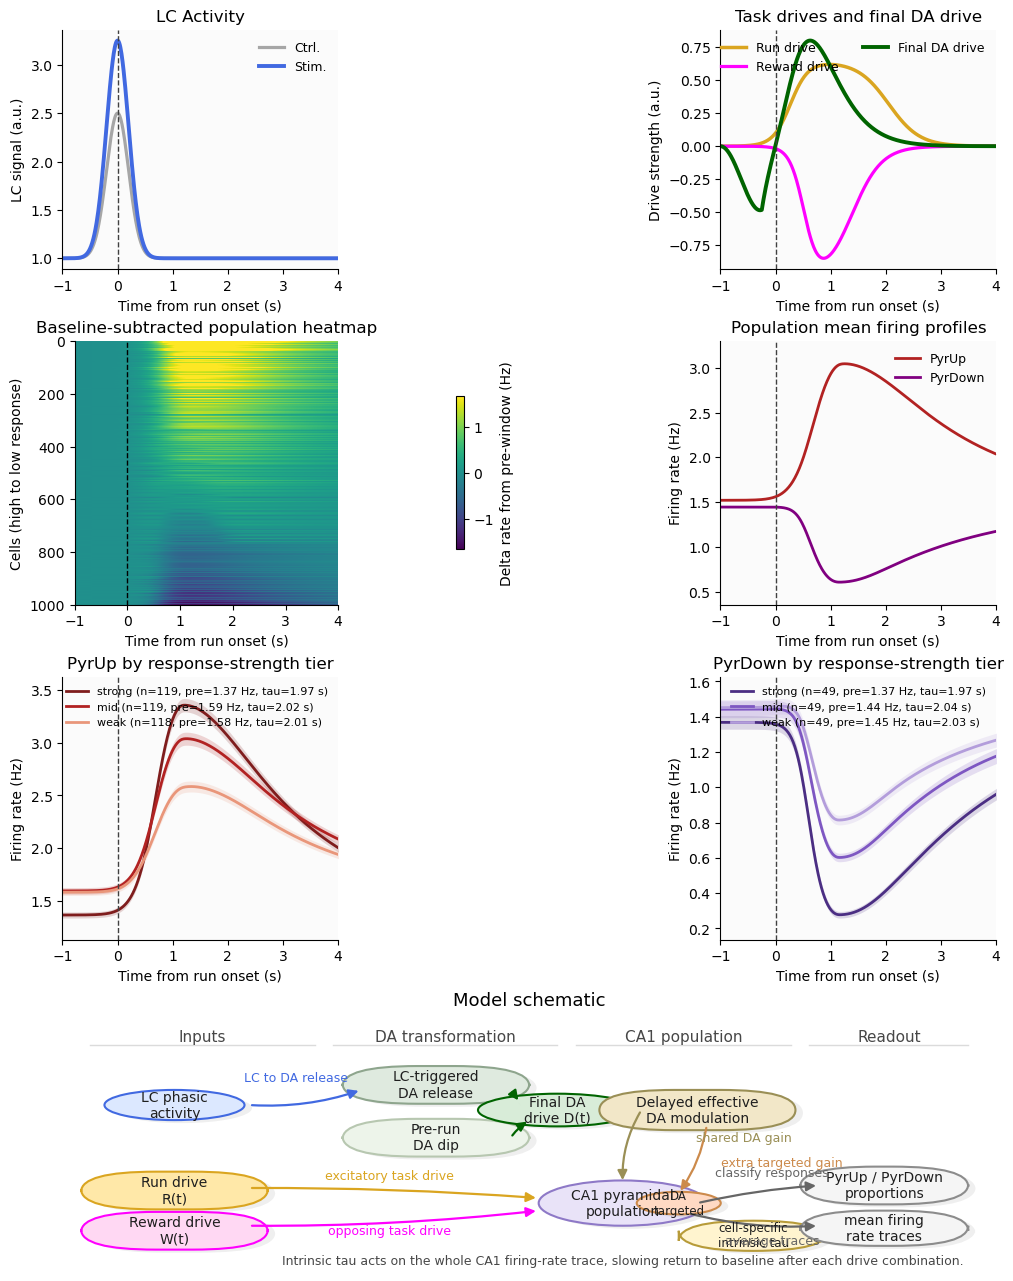

In [190]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Ellipse

t_ref = results['t']
rng_ref = np.random.default_rng(p.seed_start)
ref_pop = make_population(p, rng_ref)

p_ref_lc = deepcopy(p)
p_ref_lc.lc_amp = p.lc_amp * p.lc_activation_fold

ref_base = simulate_population_condition(t_ref, p, ref_pop, da_scale=1.0)
ref_lc = simulate_population_condition(t_ref, p_ref_lc, ref_pop, da_scale=1.0)

pre_mask = window_mask(t_ref, p.pre_window)
pre_means = np.mean(ref_base['rates'][:, pre_mask], axis=1)
resp = ref_base['resp']
tau_intr = ref_pop['tau_intr']

sort_order = np.argsort(resp)[::-1]
t_mask = (t_ref >= -1.0) & (t_ref <= 4.0)
heatmap = baseline_subtracted_traces(ref_base['rates'], t_ref, p.pre_window)[sort_order][:, t_mask]
heat_lim = np.nanpercentile(np.abs(heatmap), 97)
if not np.isfinite(heat_lim) or heat_lim <= 0:
    heat_lim = 1.0


def tertile_groups(class_mask, values, descending=True):
    idx = np.flatnonzero(class_mask)
    if len(idx) == 0:
        return {'strong': np.array([], dtype=int), 'mid': np.array([], dtype=int), 'weak': np.array([], dtype=int)}
    order = np.argsort(values[idx])
    if descending:
        order = order[::-1]
    ordered = idx[order]
    groups = np.array_split(ordered, 3)
    return {
        'strong': groups[0],
        'mid': groups[1],
        'weak': groups[2],
    }


up_groups = tertile_groups(ref_base['classes']['is_up'], resp, descending=True)
down_groups = tertile_groups(ref_base['classes']['is_down'], resp, descending=False)

up_group_colors = {
    'strong': '#7f1d1d',
    'mid': 'firebrick',
    'weak': '#e9967a',
}

down_group_colors = {
    'strong': '#4b2e83',
    'mid': '#7e57c2',
    'weak': '#b39ddb',
}


def group_label(prefix, idx):
    if len(idx) == 0:
        return f'{prefix} (n=0)'
    return (
        f'{prefix} '
        f'(n={len(idx)}, pre={np.mean(pre_means[idx]):.2f} Hz, tau={np.mean(tau_intr[idx]):.2f} s)'
    )


def add_node(ax, center, width, height, text, facecolor, edgecolor, shape='ellipse', fontsize=10, lw=1.5):
    shadow_offset = (0.008, -0.012)
    if shape == 'ellipse':
        shadow = Ellipse((center[0] + shadow_offset[0], center[1] + shadow_offset[1]), width, height, facecolor='0.2', edgecolor='none', alpha=0.08)
        patch = Ellipse(center, width, height, facecolor=facecolor, edgecolor=edgecolor, linewidth=lw)
    else:
        x0 = center[0] - width / 2
        y0 = center[1] - height / 2
        shadow = FancyBboxPatch(
            (x0 + shadow_offset[0], y0 + shadow_offset[1]),
            width,
            height,
            boxstyle='round,pad=0.02,rounding_size=0.08',
            facecolor='0.2',
            edgecolor='none',
            alpha=0.08,
        )
        patch = FancyBboxPatch(
            (x0, y0),
            width,
            height,
            boxstyle='round,pad=0.02,rounding_size=0.08',
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=lw,
        )
    ax.add_patch(shadow)
    ax.add_patch(patch)
    ax.text(center[0], center[1], text, ha='center', va='center', fontsize=fontsize, color='0.12')
    return patch


def add_arrow(ax, start, end, color='0.30', lw=1.6, text=None, text_xy=None, connectionstyle='arc3'):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle='-|>',
        mutation_scale=14,
        linewidth=lw,
        color=color,
        connectionstyle=connectionstyle,
    )
    ax.add_patch(arrow)
    if text is not None and text_xy is not None:
        ax.text(text_xy[0], text_xy[1], text, fontsize=9, ha='center', va='center', color=color)
    return arrow


fig = plt.figure(figsize=(10.0, 12.7), constrained_layout=True)
gs = fig.add_gridspec(4, 2, height_ratios=[1.0, 1.1, 1.1, 1.05], wspace=0.18)

ax_lc = fig.add_subplot(gs[0, 0])
ax_drives = fig.add_subplot(gs[0, 1])
ax_heat = fig.add_subplot(gs[1, 0])
ax_pop = fig.add_subplot(gs[1, 1])
ax_up_groups = fig.add_subplot(gs[2, 0])
ax_down_groups = fig.add_subplot(gs[2, 1])
ax_schematic = fig.add_subplot(gs[3, :])

for ax in [ax_lc, ax_drives, ax_heat, ax_pop, ax_up_groups, ax_down_groups]:
    ax.set_facecolor('#fbfbfb')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax_lc.plot(t_ref, ref_base['drives']['L'], color='0.65', linewidth=2.3, label='Ctrl.')
ax_lc.plot(t_ref, ref_lc['drives']['L'], color='royalblue', linewidth=2.8, label='Stim.')
ax_lc.axvline(0, linestyle='--', color='0.25', linewidth=1)
ax_lc.set_xlim([-1.0, 4.0])
ax_lc.set_xlabel('Time from run onset (s)')
ax_lc.set_ylabel('LC signal (a.u.)')
ax_lc.set_title('LC Activity')
ax_lc.legend(frameon=False, fontsize=9, loc='upper right')

ax_drives.plot(t_ref, ref_base['drives']['R'], color='goldenrod', linewidth=2.5, label='Run drive')
ax_drives.plot(t_ref, ref_base['drives']['W'], color='magenta', linewidth=2.3, label='Reward drive')
ax_drives.plot(t_ref, ref_base['drives']['D'], color='darkgreen', linewidth=2.8, label='Final DA drive')
ax_drives.axvline(0, linestyle='--', color='0.25', linewidth=1)
ax_drives.set_xlim([-1.0, 4.0])
ax_drives.set_xlabel('Time from run onset (s)')
ax_drives.set_ylabel('Drive strength (a.u.)')
ax_drives.set_title('Task drives and final DA drive')
ax_drives.legend(frameon=False, fontsize=9, ncol=2, loc='upper right')

im = ax_heat.imshow(
    heatmap,
    aspect='auto',
    cmap='viridis',
    extent=[t_ref[t_mask][0], t_ref[t_mask][-1], heatmap.shape[0], 0],
    vmin=-heat_lim,
    vmax=heat_lim,
    interpolation='nearest',
)
ax_heat.axvline(0, linestyle='--', color='k', linewidth=1)
ax_heat.set_xlim([-1.0, 4.0])
ax_heat.set_xlabel('Time from run onset (s)')
ax_heat.set_ylabel('Cells (high to low response)')
ax_heat.set_title('Baseline-subtracted population heatmap')
ax_heat.set_box_aspect(1)
cbar = fig.colorbar(im, ax=ax_heat, shrink=0.58, pad=0.02)
cbar.set_label('Delta rate from pre-window (Hz)')

plot_mean_sem(ax_pop, t_ref, results['base_up_traces'], class_colors['is_up'], 'PyrUp')
plot_mean_sem(ax_pop, t_ref, results['base_down_traces'], class_colors['is_down'], 'PyrDown')
ax_pop.axvline(0, linestyle='--', color='0.25', linewidth=1)
ax_pop.set_xlim([-1.0, 4.0])
set_trace_ylim(ax_pop, results['base_up_traces'], results['base_down_traces'], pad_frac=0.10, lower_floor=0.0)
ax_pop.set_xlabel('Time from run onset (s)')
ax_pop.set_ylabel('Firing rate (Hz)')
ax_pop.set_title('Population mean firing profiles')
ax_pop.legend(frameon=False, fontsize=9, loc='upper right')

for key in ['strong', 'mid', 'weak']:
    idx = up_groups[key]
    if len(idx) > 1:
        plot_mean_sem(ax_up_groups, t_ref, ref_base['rates'][idx], up_group_colors[key], group_label(key, idx))
ax_up_groups.axvline(0, linestyle='--', color='0.25', linewidth=1)
ax_up_groups.set_xlim([-1.0, 4.0])
set_trace_ylim(ax_up_groups, *(ref_base['rates'][idx] for idx in up_groups.values() if len(idx) > 1), pad_frac=0.10, lower_floor=0.0)
ax_up_groups.set_xlabel('Time from run onset (s)')
ax_up_groups.set_ylabel('Firing rate (Hz)')
ax_up_groups.set_title('PyrUp by response-strength tier')
ax_up_groups.legend(frameon=False, fontsize=8, loc='upper right')

for key in ['strong', 'mid', 'weak']:
    idx = down_groups[key]
    if len(idx) > 1:
        plot_mean_sem(ax_down_groups, t_ref, ref_base['rates'][idx], down_group_colors[key], group_label(key, idx))
ax_down_groups.axvline(0, linestyle='--', color='0.25', linewidth=1)
ax_down_groups.set_xlim([-1.0, 4.0])
set_trace_ylim(ax_down_groups, *(ref_base['rates'][idx] for idx in down_groups.values() if len(idx) > 1), pad_frac=0.10, lower_floor=0.0)
ax_down_groups.set_xlabel('Time from run onset (s)')
ax_down_groups.set_ylabel('Firing rate (Hz)')
ax_down_groups.set_title('PyrDown by response-strength tier')
ax_down_groups.legend(frameon=False, fontsize=8, loc='upper right')

ax_schematic.axis('off')
ax_schematic.set_xlim(0, 1)
ax_schematic.set_ylim(0, 1)
ax_schematic.set_title('Model schematic', fontsize=13, pad=10)

for x0, x1, label in [(0.03, 0.27, 'Inputs'), (0.29, 0.53, 'DA transformation'), (0.55, 0.78, 'CA1 population'), (0.80, 0.97, 'Readout')]:
    ax_schematic.plot([x0, x1], [0.90, 0.90], color='0.86', linewidth=1.0)
    ax_schematic.text((x0 + x1) / 2, 0.93, label, ha='center', va='center', fontsize=11, color='0.28')

add_node(ax_schematic, (0.12, 0.66), 0.15, 0.12, 'LC phasic\nactivity', '#dce8ff', 'royalblue', shape='ellipse')
add_node(ax_schematic, (0.12, 0.32), 0.16, 0.11, 'Run drive\nR(t)', '#ffe8a8', 'goldenrod', shape='pill')
add_node(ax_schematic, (0.12, 0.16), 0.16, 0.11, 'Reward drive\nW(t)', '#ffd8f3', 'magenta', shape='pill')

add_node(ax_schematic, (0.40, 0.74), 0.16, 0.11, 'LC-triggered\nDA release', '#dfeadf', '#8ea58d', shape='pill')
add_node(ax_schematic, (0.40, 0.53), 0.16, 0.11, 'Pre-run\nDA dip', '#edf4ea', '#b7c7b0', shape='pill')
add_node(ax_schematic, (0.53, 0.64), 0.17, 0.13, 'Final DA\ndrive D(t)', '#d8ecd8', 'darkgreen', shape='ellipse')
add_node(ax_schematic, (0.68, 0.64), 0.17, 0.12, 'Delayed effective\nDA modulation', '#f2e7c8', '#9a8f56', shape='pill')

add_node(ax_schematic, (0.60, 0.27), 0.18, 0.18, 'CA1 pyramidal\npopulation', '#e9e3f8', '#8e79c7', shape='ellipse')
add_node(ax_schematic, (0.66, 0.27), 0.09, 0.09, 'DA\ntargeted', '#ffd9c3', '#cc8a4b', shape='ellipse', fontsize=8.5)
add_node(ax_schematic, (0.74, 0.14), 0.12, 0.08, 'cell-specific\nintrinsic tau', '#fff4cf', '#b79b39', shape='pill', fontsize=8.5)

add_node(ax_schematic, (0.88, 0.34), 0.14, 0.11, 'PyrUp / PyrDown\nproportions', '#f5f5f5', '0.55', shape='pill')
add_node(ax_schematic, (0.88, 0.17), 0.14, 0.10, 'mean firing\nrate traces', '#f5f5f5', '0.55', shape='pill')

add_arrow(ax_schematic, (0.20, 0.66), (0.32, 0.72), color='royalblue', text='LC to DA release', text_xy=(0.25, 0.77), connectionstyle='arc3,rad=0.10')
add_arrow(ax_schematic, (0.48, 0.72), (0.49, 0.67), color='darkgreen', connectionstyle='arc3')
add_arrow(ax_schematic, (0.48, 0.53), (0.50, 0.60), color='darkgreen', connectionstyle='arc3,rad=-0.10')
add_arrow(ax_schematic, (0.62, 0.64), (0.60, 0.35), color='#9a8f56', text='shared DA gain', text_xy=(0.73, 0.53), connectionstyle='arc3,rad=0.15')
add_arrow(ax_schematic, (0.69, 0.58), (0.66, 0.31), color='#cc8a4b', text='extra targeted gain', text_xy=(0.77, 0.43), connectionstyle='arc3,rad=-0.12')
add_arrow(ax_schematic, (0.20, 0.33), (0.51, 0.29), color='goldenrod', text='excitatory task drive', text_xy=(0.35, 0.38), connectionstyle='arc3,rad=-0.02')
add_arrow(ax_schematic, (0.20, 0.18), (0.51, 0.24), color='magenta', text='opposing task drive', text_xy=(0.35, 0.16), connectionstyle='arc3,rad=0.03')
add_arrow(ax_schematic, (0.68, 0.27), (0.81, 0.34), color='0.40', text='classify responses', text_xy=(0.76, 0.39), connectionstyle='arc3,rad=-0.04')
add_arrow(ax_schematic, (0.67, 0.23), (0.81, 0.18), color='0.40', text='average traces', text_xy=(0.76, 0.12), connectionstyle='arc3,rad=0.08')

ax_schematic.text(
    0.60,
    0.04,
    'Intrinsic tau acts on the whole CA1 firing-rate trace, slowing return to baseline after each drive combination.',
    ha='center',
    va='center',
    fontsize=9,
    color='0.28',
)

plt.show()


## 1. Baseline PyrUp and PyrDown Population Means

These panels separate the baseline PyrUp and PyrDown population mean firing profiles so they can be shown directly in the progress report as mean +/- SEM curves.


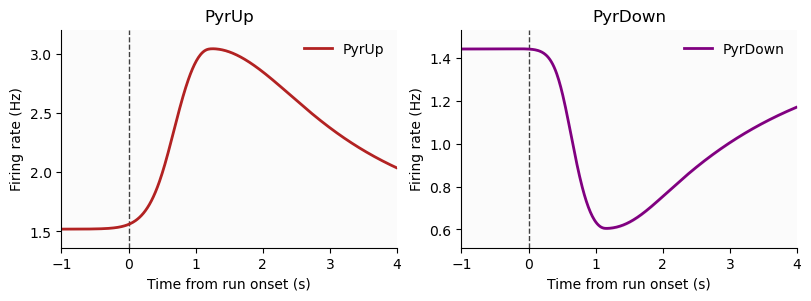

In [191]:
fig, axes = plt.subplots(1, 2, figsize=(8.0, 2.9), constrained_layout=True)

for ax in axes:
    ax.set_facecolor('#fbfbfb')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axvline(0, linestyle='--', color='0.25', linewidth=1)
    ax.set_xlim([-1.0, 4.0])
    ax.set_xlabel('Time from run onset (s)')
    ax.set_ylabel('Firing rate (Hz)')

plot_mean_sem(axes[0], results['t'], results['base_up_traces'], class_colors['is_up'], 'PyrUp')
set_trace_ylim(axes[0], results['base_up_traces'], pad_frac=0.10, lower_floor=0.0)
axes[0].set_title('PyrUp')
axes[0].legend(frameon=False)

plot_mean_sem(axes[1], results['t'], results['base_down_traces'], class_colors['is_down'], 'PyrDown')
set_trace_ylim(axes[1], results['base_down_traces'], pad_frac=0.10, lower_floor=0.0)
axes[1].set_title('PyrDown')
axes[1].legend(frameon=False)

plt.show()


## 2. LC Activation Profiles for PyrUp and PyrDown

These panels isolate the LC-manipulation effect on PyrUp and PyrDown profiles. Baseline traces are plotted in the class colours, and the `1.5x LC` manipulation is plotted in `royalblue` for both populations.


Wilc p = 1.9073486328125e-06
ttest p = 1.0378175161342292e-18


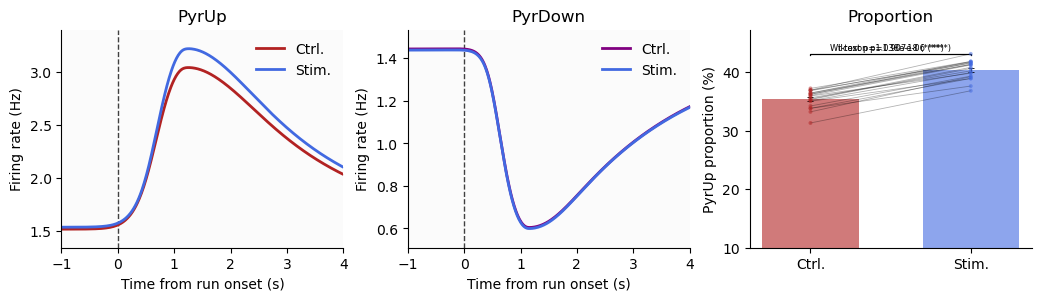

LC activation summary (mean +/- SEM):
  Ctrl. PyrUp (%): 35.38 +/- 0.33 SEM
  Stim. PyrUp (%): 40.36 +/- 0.35 SEM
  PyrUp proportion shift (%): delta = 4.98, paired t p = <1e-4, Wilcoxon p = <1e-4
  Ctrl. PyrDown (%): 13.93 +/- 0.21 SEM
  Stim. PyrDown (%): 13.46 +/- 0.21 SEM
  PyrDown proportion shift (%): delta = -0.46, paired t p = <1e-4, Wilcoxon p = 0.0001


In [192]:
fig, axes = plt.subplots(1, 3, figsize=(10.3, 2.9), constrained_layout=True)

for ax in axes[:2]:
    ax.set_facecolor('#fbfbfb')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axvline(0, linestyle='--', color='0.25', linewidth=1)
    ax.set_xlim([-1.0, 4.0])
    ax.set_xlabel('Time from run onset (s)')
    ax.set_ylabel('Firing rate (Hz)')

plot_mean_sem(axes[0], results['t'], results['base_up_traces'], class_colors['is_up'], 'Ctrl.')
plot_mean_sem(axes[0], results['t'], results['lc_up_traces'], condition_colors['lc'], 'Stim.')
set_trace_ylim(axes[0], results['base_up_traces'], results['lc_up_traces'], pad_frac=0.10, lower_floor=0.0)
axes[0].set_title('PyrUp')
axes[0].legend(frameon=False)

plot_mean_sem(axes[1], results['t'], results['base_down_traces'], class_colors['is_down'], 'Ctrl.')
plot_mean_sem(axes[1], results['t'], results['lc_down_traces'], condition_colors['lc'], 'Stim.')
set_trace_ylim(axes[1], results['base_down_traces'], results['lc_down_traces'], pad_frac=0.10, lower_floor=0.0)
axes[1].set_title('PyrDown')
axes[1].legend(frameon=False)

pf.plot_bar_with_paired_scatter(
    axes[2],
    results['stats']['base_up_pct'],
    results['stats']['lc_up_pct'],
    colors=(class_colors['is_up'], condition_colors['lc']),
    title='Proportion',
    ylabel='PyrUp proportion (%)',
    xticklabels=('Ctrl.', 'Stim.'),
    ylim=paired_ylim(results['stats']['base_up_pct'], results['stats']['lc_up_pct'], min_pad=3.0, anchor_floor=10.0),
)

plt.show()

print('LC activation summary (mean +/- SEM):')
print_summary_line('  Ctrl. PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line('  Stim. PyrUp (%)', results['stats']['lc_up_pct'])
print_paired_summary('  PyrUp proportion shift (%)', results['stats']['base_up_pct'], results['stats']['lc_up_pct'])
print_summary_line('  Ctrl. PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line('  Stim. PyrDown (%)', results['stats']['lc_down_pct'])
print_paired_summary('  PyrDown proportion shift (%)', results['stats']['base_down_pct'], results['stats']['lc_down_pct'])


## 3. DA-Targeted CA1 Cells Are More Likely PyrUp and More Active

This panel uses the baseline condition only. LC now peaks at run onset and the LC-triggered DA release peaks shortly after run onset, while the effective DA modulation of CA1 rises smoothly only after run onset, so the intended targeted-vs-nontargeted separation remains mainly post-run rather than a pre-run bump.

Wilc p = 0.0007076263427734375
ttest p = 0.0008367475908014199


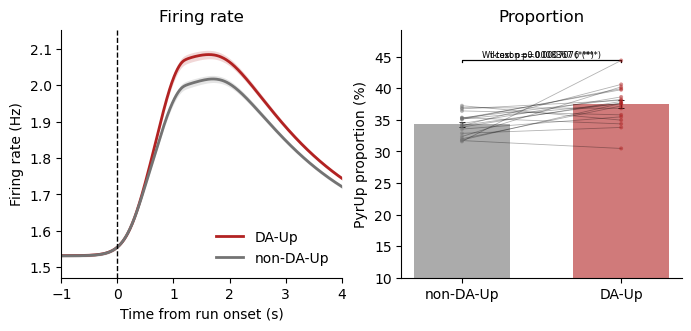

DA-targeting summary (mean +/- SEM):
  P(PyrUp | DA-Up) (%): 37.48 +/- 0.66 SEM
  P(PyrUp | non-DA-Up) (%): 34.29 +/- 0.41 SEM
  PyrUp proportion difference (%): delta = 3.19, paired t p = 0.0008, Wilcoxon p = 0.0015
  Post-run rate, DA-Up (Hz): 2.05 +/- 0.01 SEM
  Post-run rate, non-DA-Up (Hz): 1.99 +/- 0.01 SEM
  Post-run firing-rate difference (Hz): delta = 0.06, paired t p = 0.0011, Wilcoxon p = 0.0019


In [193]:
fig, axes = plt.subplots(1, 2, figsize=(6.8, 3.2), constrained_layout=True)

plot_mean_sem(axes[0], results['t'], results['targeted_traces'], condition_colors['da_targeted'], 'DA-Up')
plot_mean_sem(axes[0], results['t'], results['non_targeted_traces'], condition_colors['not_targeted'], 'non-DA-Up')
axes[0].axvline(0, linestyle='--', color='k', linewidth=1)
axes[0].set_xlim([-1.0, 4.0])
axes[0].set_xlabel('Time from run onset (s)')
axes[0].set_ylabel('Firing rate (Hz)')
set_trace_ylim(axes[0], results['targeted_traces'], results['non_targeted_traces'], pad_frac=0.10, lower_floor=0.0)
axes[0].set_title('Firing rate')
axes[0].legend(frameon=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

pf.plot_bar_with_paired_scatter(
    axes[1],
    results['stats']['p_up_not_targeted'],
    results['stats']['p_up_da_targeted'],
    colors=(condition_colors['not_targeted'], condition_colors['da_targeted']),
    title='Proportion',
    ylabel='PyrUp proportion (%)',
    xticklabels=('non-DA-Up', 'DA-Up'),
    ylim=paired_ylim(results['stats']['p_up_not_targeted'], results['stats']['p_up_da_targeted'], min_pad=3.0, anchor_floor=10.0),
)

plt.show()

print('DA-targeting summary (mean +/- SEM):')
print_summary_line('  P(PyrUp | DA-Up) (%)', results['stats']['p_up_da_targeted'])
print_summary_line('  P(PyrUp | non-DA-Up) (%)', results['stats']['p_up_not_targeted'])
print_paired_summary('  PyrUp proportion difference (%)', results['stats']['p_up_not_targeted'], results['stats']['p_up_da_targeted'])
print_summary_line('  Post-run rate, DA-Up (Hz)', results['stats']['post_rate_da_targeted'])
print_summary_line('  Post-run rate, non-DA-Up (Hz)', results['stats']['post_rate_not_targeted'])
print_paired_summary('  Post-run firing-rate difference (Hz)', results['stats']['post_rate_not_targeted'], results['stats']['post_rate_da_targeted'])


## 4. Partial DA Blockade in CA1

Within each bootstrap replicate, the DA blockade condition is implemented as a **partial reduction of effective DA efficacy** on the same synthetic population used for baseline. In this version the manipulation scales the smooth post-run DA modulatory signal inside CA1, so a stronger partial block primarily increases post-run firing-rate and PyrUp-fraction differences rather than changing the pre-run baseline.

Wilc p = 1.9073486328125e-06
ttest p = 3.941990182033912e-15
Wilc p = 1.9073486328125e-06
ttest p = 1.1306016956854241e-07


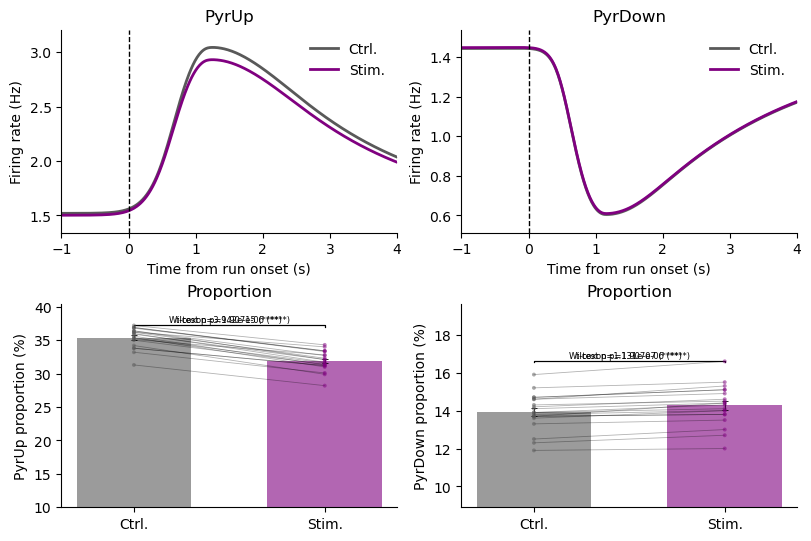

Partial DA blockade summary (mean +/- SEM):
  Ctrl. PyrUp (%): 35.38 +/- 0.33 SEM
  Stim. PyrUp (%): 31.90 +/- 0.33 SEM
  PyrUp proportion shift (%): delta = -3.48, paired t p = <1e-4, Wilcoxon p = <1e-4
  Ctrl. PyrDown (%): 13.93 +/- 0.21 SEM
  Stim. PyrDown (%): 14.28 +/- 0.23 SEM
  PyrDown proportion shift (%): delta = 0.35, paired t p = <1e-4, Wilcoxon p = <1e-4


In [194]:
fig, axes = plt.subplots(2, 2, figsize=(8.0, 5.3), constrained_layout=True)

plot_mean_sem(axes[0, 0], results['t'], results['base_up_traces'], condition_colors['baseline'], 'Ctrl.')
plot_mean_sem(axes[0, 0], results['t'], results['block_up_traces'], condition_colors['blocked'], 'Stim.')
axes[0, 0].axvline(0, linestyle='--', color='k', linewidth=1)
axes[0, 0].set_xlim([-1.0, 4.0])
axes[0, 0].set_xlabel('Time from run onset (s)')
axes[0, 0].set_ylabel('Firing rate (Hz)')
set_trace_ylim(axes[0, 0], results['base_up_traces'], results['block_up_traces'], pad_frac=0.10, lower_floor=0.0)
axes[0, 0].set_title('PyrUp')
axes[0, 0].legend(frameon=False)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

plot_mean_sem(axes[0, 1], results['t'], results['base_down_traces'], condition_colors['baseline'], 'Ctrl.')
plot_mean_sem(axes[0, 1], results['t'], results['block_down_traces'], condition_colors['blocked'], 'Stim.')
axes[0, 1].axvline(0, linestyle='--', color='k', linewidth=1)
axes[0, 1].set_xlim([-1.0, 4.0])
axes[0, 1].set_xlabel('Time from run onset (s)')
axes[0, 1].set_ylabel('Firing rate (Hz)')
set_trace_ylim(axes[0, 1], results['base_down_traces'], results['block_down_traces'], pad_frac=0.10, lower_floor=0.0)
axes[0, 1].set_title('PyrDown')
axes[0, 1].legend(frameon=False)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

pf.plot_bar_with_paired_scatter(
    axes[1, 0],
    results['stats']['base_up_pct'],
    results['stats']['block_up_pct'],
    colors=(condition_colors['baseline'], condition_colors['blocked']),
    title='Proportion',
    ylabel='PyrUp proportion (%)',
    xticklabels=('Ctrl.', 'Stim.'),
    ylim=paired_ylim(results['stats']['base_up_pct'], results['stats']['block_up_pct'], min_pad=3.0, anchor_floor=10.0),
)

pf.plot_bar_with_paired_scatter(
    axes[1, 1],
    results['stats']['base_down_pct'],
    results['stats']['block_down_pct'],
    colors=(condition_colors['baseline'], condition_colors['blocked']),
    title='Proportion',
    ylabel='PyrDown proportion (%)',
    xticklabels=('Ctrl.', 'Stim.'),
    ylim=paired_ylim(results['stats']['base_down_pct'], results['stats']['block_down_pct'], min_pad=3.0, anchor_floor=10.0),
)

plt.show()

print('Partial DA blockade summary (mean +/- SEM):')
print_summary_line('  Ctrl. PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line('  Stim. PyrUp (%)', results['stats']['block_up_pct'])
print_paired_summary('  PyrUp proportion shift (%)', results['stats']['base_up_pct'], results['stats']['block_up_pct'])
print_summary_line('  Ctrl. PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line('  Stim. PyrDown (%)', results['stats']['block_down_pct'])
print_paired_summary('  PyrDown proportion shift (%)', results['stats']['base_down_pct'], results['stats']['block_down_pct'])


## Interpretation and Caveats

This notebook should be read as a **phenomenological systems-neuroscience model**, not a detailed biophysical circuit model.

What this tuned branch is meant to provide:
- paired synthetic-population comparisons for baseline, `1.5x` LC activation, and partial DA blockade
- a current-based DA formulation in which dopamine contributes an additive modulatory current before the intrinsic tau update, with `softplus` applied only at the output stage
- a parameter regime that keeps the manuscript-style experimental effects in range while using fixed class-definition thresholds
- a compact visual summary of how LC, DA, task drives, and intrinsic recovery combine to shape PyrUp and PyrDown responses

What it still does not provide:
- direct uncertainty estimates from the recorded experimental cells
- recurrent CA1 circuitry, receptor-specific DA mechanisms, or trial-to-trial variability
- proof that the biological circuit uses these exact equations or parameter values

The correct interpretation is therefore limited: the model supports the internal logic of the LC-DA-CA1 account and shows that the targeted experimental signatures can coexist in one coherent synthetic-population regime, but it remains an explanatory abstraction rather than a fitted circuit model.
